In [14]:
!pip install mediapipe==0.10.14



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 9.0 MB/s eta 0:00:00


In [1]:
import mediapipe as mp
mp_hands = mp.solutions.hands.Hands()
print("MediaPipe is ready!")


MediaPipe is ready!


In [2]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import cv2
import numpy as np
import base64
import io

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = '📷 Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = base64.b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename


In [3]:
from IPython.display import Image, display
import mediapipe as mp

def detect_gesture(image_path):
    mp_hands = mp.solutions.hands
    mp_drawing = mp.solutions.drawing_utils

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    with mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.7) as hands:
        result = hands.process(image_rgb)

        gesture = "No Hand Detected"

        if result.multi_hand_landmarks:
            hand_landmarks = result.multi_hand_landmarks[0]
            h, w, _ = image.shape
            lm = hand_landmarks.landmark
            lm_list = [(int(p.x * w), int(p.y * h)) for p in lm]

            fingers = []
            tip_ids = [4, 8, 12, 16, 20]

            # Thumb
            fingers.append(1 if lm_list[tip_ids[0]][0] < lm_list[tip_ids[0] - 1][0] else 0)
            # Fingers
            for i in range(1, 5):
                fingers.append(1 if lm_list[tip_ids[i]][1] < lm_list[tip_ids[i] - 2][1] else 0)

            total_fingers = sum(fingers)
            if total_fingers == 0:
                gesture = "Fist"
            elif total_fingers == 1:
                gesture = "One Finger"
            elif total_fingers == 5:
                gesture = "Open Palm"
            else:
                gesture = f"{total_fingers} Fingers"

            mp_drawing.draw_landmarks(image, hand_landmarks, mp_hands.HAND_CONNECTIONS)

        # Show image
        _, encoded_img = cv2.imencode('.jpg', image)
        display(Image(data=encoded_img.tobytes()))
        print(f"Detected Gesture: {gesture}")


<IPython.core.display.Javascript object>

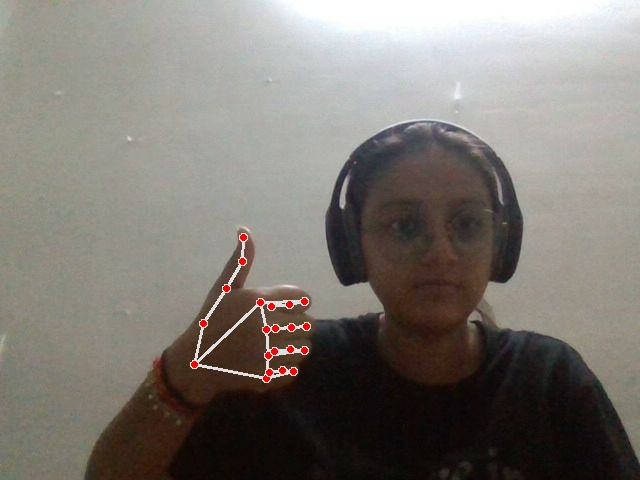

Detected Gesture: Fist


In [10]:
filename = take_photo()
detect_gesture(filename)


In [9]:
!pip install streamlit mediapipe opencv-python pyngrok


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.9 MB/s eta 0:00:00
